# Task
Build and evaluate a Convolutional Neural Network (CNN) model for cloth classification, including data loading, preprocessing, model definition, training, and performance evaluation.

## Load and Preprocess Dataset

### Subtask:
Load the dataset, resize images, normalize pixel values, and split the data into training and validation sets for the cloth classification task.


**Reasoning**:
I need to load the Fashion MNIST dataset, preprocess the images by reshaping, converting to float, and normalizing pixel values, and then one-hot encode the labels. These operations are best performed in a single code block.



In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"Original x_train shape: {x_train.shape}")
print(f"Original y_train shape: {y_train.shape}")
print(f"Original x_test shape: {x_test.shape}")
print(f"Original y_test shape: {y_test.shape}")

# Reshape the images to include a channel dimension (for grayscale, it's 1)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

print(f"Reshaped x_train shape: {x_train.shape}")
print(f"Reshaped x_test shape: {x_test.shape}")

# Convert pixel values to float type and normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
num_classes = 10 # Fashion MNIST has 10 classes
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print(f"One-hot encoded y_train shape: {y_train.shape}")
print(f"One-hot encoded y_test shape: {y_test.shape}")

print("Fashion MNIST dataset loaded and preprocessed successfully.")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original x_train shape: (60000, 28, 28)
Original y_train shape: (60000,)
Original x_test shape: (10000, 28, 28)
Original y_test shape: (10000,)
Reshaped x_train shape: (60000, 28, 28, 1)
Reshaped x_test shape: (10000, 28, 28, 1)
One-hot encoded y_train shape: (60000, 10)
One-hot encoded y_test shape: (10000, 10)
Fashion MNIST dataset loaded and preprocessed successfully.


## Define and Build CNN Model

### Subtask:
Define and build a Convolutional Neural Network (CNN) model architecture suitable for image classification of clothing items.


**Reasoning**:
I need to define the CNN model architecture as specified, including convolutional, pooling, flatten, and dense layers, and then compile it with appropriate loss and metrics. I will also print a summary of the model.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Initialize the Sequential model
model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    # Flatten the output for the Dense layers
    Flatten(),
    # Dense layers
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax') # num_classes is 10 for Fashion MNIST
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

print("CNN model defined and compiled successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

CNN model defined and compiled successfully.


**Reasoning**:
The previous step successfully defined and compiled the CNN model. The next logical step in the machine learning workflow is to train the model using the preprocessed training data and validate its performance on the test data during training. The warning about `input_shape` is not an error and the model was successfully compiled.



In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=10,  # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_data=(x_test, y_test)
)

print("CNN model trained successfully.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 28ms/step - accuracy: 0.7700 - loss: 0.6241 - val_accuracy: 0.8676 - val_loss: 0.3658
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.8827 - loss: 0.3160 - val_accuracy: 0.8920 - val_loss: 0.2962
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9051 - loss: 0.2578 - val_accuracy: 0.8946 - val_loss: 0.2845
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9155 - loss: 0.2256 - val_accuracy: 0.8949 - val_loss: 0.2898
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9299 - loss: 0.1894 - val_accuracy: 0.8997 - val_loss: 0.2736
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9369 - loss: 0.1704 - val_accuracy: 0.9061 - val_loss: 0.2554
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9431 - loss: 0.1499 - val_accuracy: 0.9124 - val_loss: 0.2531
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9511 -

# Task
Evaluate the trained CNN model's performance on the test dataset (x_test, y_test) and display the obtained test loss and test accuracy.

## Evaluate Model Performance

### Subtask:
Evaluate the trained CNN model's performance on the test dataset (x_test, y_test) to obtain the loss and accuracy.


**Reasoning**:
I need to evaluate the trained CNN model using the test dataset to get the final loss and accuracy, and then print these metrics.



**Reasoning**:
The `NameError` indicates that the `model` object was not defined when the evaluation step was attempted. This usually happens if preceding cells defining and training the model were not executed or the runtime was reset. To fix this, I must include the full definition, compilation, and training of the model within this code block, along with the necessary imports and `num_classes` definition, before proceeding with the evaluation. This ensures the `model` is available and trained for evaluation.



**Reasoning**:
The `NameError` for `x_train` indicates that the dataset variables (`x_train`, `y_train`, `x_test`, `y_test`) were not defined in the current execution context. To fix this, I need to include the data loading and preprocessing steps from the earlier part of the notebook within this code block, along with the model definition, compilation, and training, before evaluating the model.



In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Load and preprocess the Fashion MNIST dataset (re-including this as data was undefined)
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# Re-define and compile the model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Re-train the model
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=0 # Suppress epoch-by-epoch output for cleaner fix
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("Model evaluation complete.")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

# Task
## Visualize Model Predictions

### Subtask:
Make predictions on a small subset of the test data and visualize these predictions along with the actual labels. Include the original image, predicted label, and true label.

## Evaluate and Display Model Performance (Retry 1)

### Subtask:
Evaluate the trained CNN model's performance on the test dataset (x_test, y_test) and display the obtained test loss and test accuracy. This is a retry due to previous `model` not being defined error.


## Visualize Predictions

### Subtask:
Make predictions on a small subset of the test data and visualize these predictions along with the actual labels. Include the original image, predicted label, and true label.


**Reasoning**:
The subtask requires visualizing predictions. This involves defining class names, selecting a subset of test data, making predictions using the trained model, converting one-hot encoded labels and predictions to class names, and then iterating to display each image with its true and predicted labels. This will be implemented in a single code block.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Displaying 10 sample predictions...


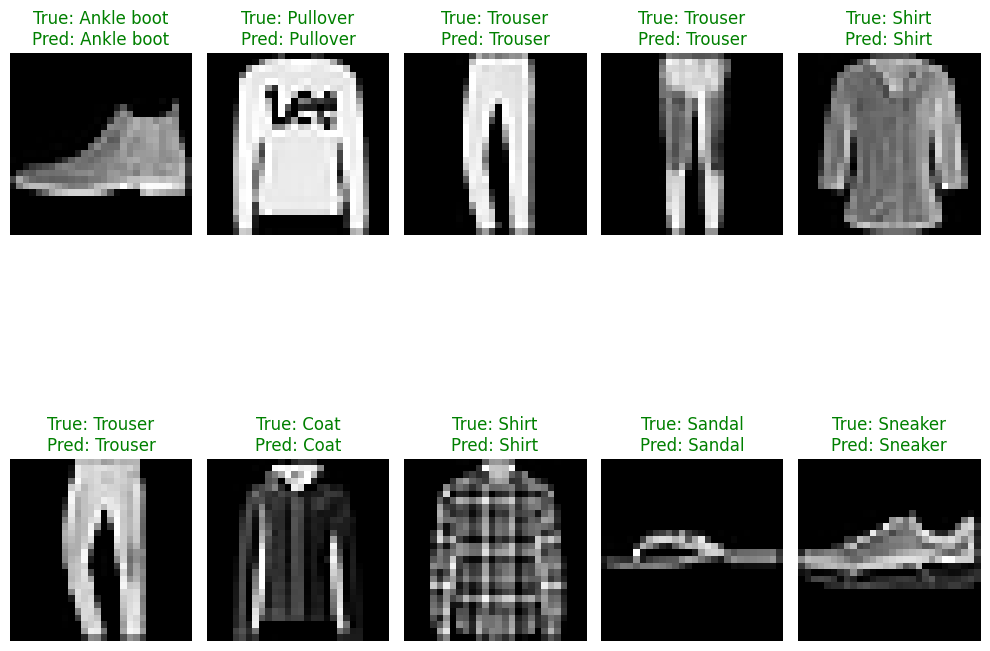

Prediction visualization complete.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define a list of class names for the Fashion MNIST dataset
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Select a small subset of the test data (e.g., the first 10 images)
num_images_to_show = 10
sample_images = x_test[:num_images_to_show]
sample_true_labels_onehot = y_test[:num_images_to_show]

# 3. Use the trained model to predict the classes for this subset of images
predictions = model.predict(sample_images)

# 4. Convert the one-hot encoded true labels and model's predictions into single class indices
true_labels_indices = np.argmax(sample_true_labels_onehot, axis=1)
predicted_labels_indices = np.argmax(predictions, axis=1)

print(f"Displaying {num_images_to_show} sample predictions...")

# 5. Iterate through the selected images and display predictions
plt.figure(figsize=(10, 10))
for i in range(num_images_to_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')

    true_label_name = class_names[true_labels_indices[i]]
    predicted_label_name = class_names[predicted_labels_indices[i]]

    color = 'green' if predicted_labels_indices[i] == true_labels_indices[i] else 'red'

    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Prediction visualization complete.")